In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.rcParams["figure.facecolor"] = "#0d0d0d"
plt.rcParams["axes.facecolor"] = "#0d0d0d"
plt.rcParams["axes.edgecolor"] = "#444444"
plt.rcParams["axes.labelcolor"] = "#f5f5f5"
plt.rcParams["text.color"] = "#f5f5f5"
plt.rcParams["xtick.color"] = "#f5f5f5"
plt.rcParams["ytick.color"] = "#f5f5f5"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

COR_VERMELHO = "#e63946"
COR_AZUL = "#457b9d"

In [2]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#2a2a2a"
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["axes.axisbelow"] = True

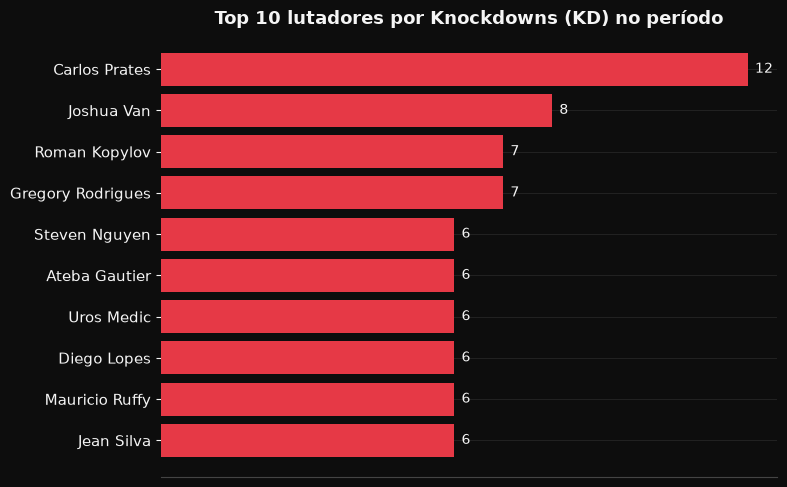

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_kd.index[::-1], top_kd.values[::-1], color=COR_VERMELHO)

for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.15, barra.get_y() + barra.get_height()/2,
            f"{int(largura)}", va="center", fontsize=10, color="#f5f5f5")

ax.set_title("Top 10 lutadores por Knockdowns (KD) no período", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_xticks([])
plt.tight_layout()
plt.savefig("../figures/top10_kd.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

In [5]:
def estilizar_grafico(ax, titulo, mostrar_eixo_x=False):
    """Aplica o padrão visual dark mode/editorial do projeto a um gráfico de barras horizontais."""
    ax.set_title(titulo, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    if not mostrar_eixo_x:
        ax.set_xticks([])


def adicionar_valores_barras(ax, barras, cor_texto="#f5f5f5"):
    """Escreve o valor numérico na ponta de cada barra horizontal."""
    for barra in barras:
        largura = barra.get_width()
        ax.text(largura + (largura * 0.02), barra.get_y() + barra.get_height()/2,
                f"{largura:.0f}" if largura == int(largura) else f"{largura:.1f}",
                va="center", fontsize=10, color=cor_texto)

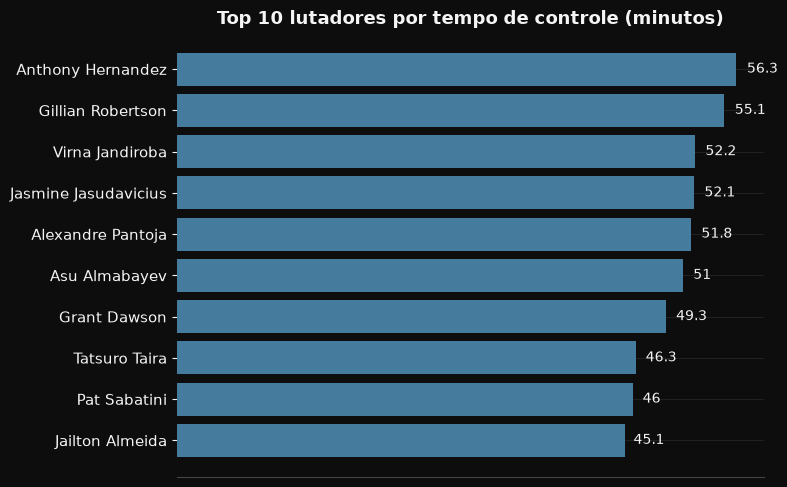

In [6]:
df_proc = pd.read_csv("../data/processed/dataset_24eventos_resumo_limpo.csv") if False else pd.read_csv("../data/processed/dataset_final_resumo_limpo.csv")

top_ctrl = df_proc.groupby("Fighter")["Ctrl_seconds"].sum().sort_values(ascending=False).head(10)
top_ctrl_min = (top_ctrl / 60).round(1)  # converter para minutos, mais legível

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.barh(top_ctrl_min.index[::-1], top_ctrl_min.values[::-1], color=COR_AZUL)

adicionar_valores_barras(ax, barras)
estilizar_grafico(ax, "Top 10 lutadores por tempo de controle (minutos)")

plt.tight_layout()
plt.savefig("../figures/top10_ctrl.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()